In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA'
)

In [3]:
ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           733
Ngn3 high EP     624
Pre-endocrine    585
Beta             573
Alpha            454
Ngn3 low EP      233
Epsilon          141
Delta             70
Name: count, dtype: int64

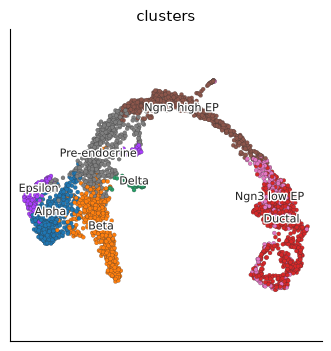

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)

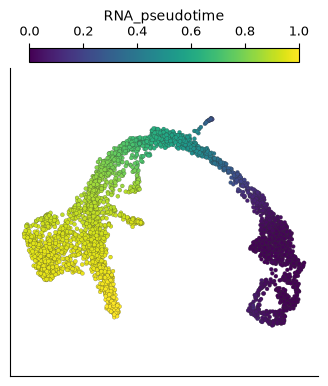

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
)

In [7]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

In [8]:
checkpoint_genes = ["Spp1", "Cpe"]
checkpoint = (
    markers.table.set_index("feature_name")
    .loc[checkpoint_genes, ["r_value", "p_value_adjusted"]]
)
checkpoint

,r_value,p_value_adjusted
feature_name,,
Spp1,-0.841547,0.0
Cpe,0.712643,0.0


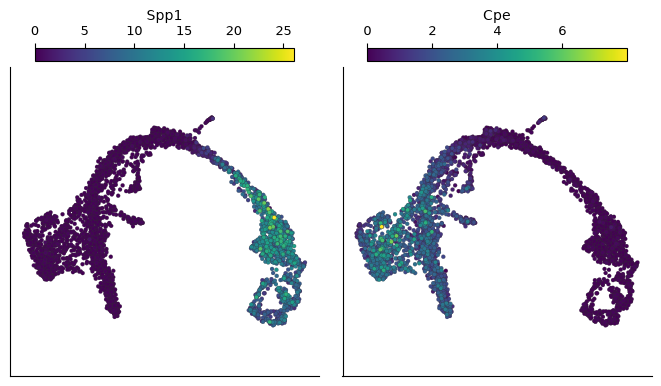

In [9]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=checkpoint_genes,
    n_columns=2,
    sort_values=True,
)